In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1" 
print(os.cpu_count())

144


In [2]:
from qulacs import QuantumState,QuantumCircuit, Observable, PauliOperator,ParametricQuantumCircuit,DensityMatrix, GeneralQuantumOperator
from qulacs.gate import H,X,Y,Z,RX,RY,RZ,CNOT,CZ,TOFFOLI,SWAP,merge,DenseMatrix,add, Probabilistic, P0, P1,to_matrix_gate,PauliRotation,Pauli, RandomUnitary
from qulacs.state import inner_product, partial_trace, tensor_product
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
import numpy as np
import statistics as stat

In [5]:
def plot_error_fill(x, ylist, label):
    cost_mean = []
    cost_stdv = []
    cost_max = []
    cost_min = []
    for i in range(len(x)):
        a = stat.mean([r[i] for r in ylist])
        b = max([r[i] for r in ylist]) 
        c = min([r[i] for r in ylist]) 
        cost_mean.append( a )
        cost_max.append( b )
        cost_min.append( c )
       
    # plot
    plt.plot(x, cost_mean, label=label, alpha=1)
    plt.fill_between(x, cost_min, cost_max, alpha=0.2)
    
    
def plot_mean1(x, ylist, label, color):
    cost_mean = []
    cost_stdv = []
    cost_max = []
    cost_min = []
    for i in range(len(x)):
        a = stat.mean([r[i] for r in ylist])
        b = max([r[i] for r in ylist]) 
        c = min([r[i] for r in ylist]) 
        cost_mean.append( a )
        cost_max.append( b )
        cost_min.append( c )
        
    # Thin out data points to improve readability.
    x2 = []
    cost_mean2 = []
    delta = 50
    for i in range(len(x)):
        if i%delta==0:
            x2.append(x[i])
            cost_mean2.append(cost_mean[i])    

    plt.plot(x2, cost_mean2, label=label, alpha=1, color=color, linestyle="dashed")

    
def plot_mean2(x, ylist, label, color):
    cost_mean = []
    cost_stdv = []
    cost_max = []
    cost_min = []
    for i in range(len(x)):
        a = stat.mean([r[i] for r in ylist])
        b = max([r[i] for r in ylist]) 
        c = min([r[i] for r in ylist]) 
        cost_mean.append( a )
        cost_max.append( b )
        cost_min.append( c )
        
    # Thin out data points to improve readability.
    x2 = []
    cost_mean2 = []
    delta = 10
    for i in range(len(x)):
        if i%delta==0:
            x2.append(x[i])
            cost_mean2.append(cost_mean[i])
        
    plt.plot(x2, cost_mean2, label=label, alpha=1, color=color, linestyle="dashed")

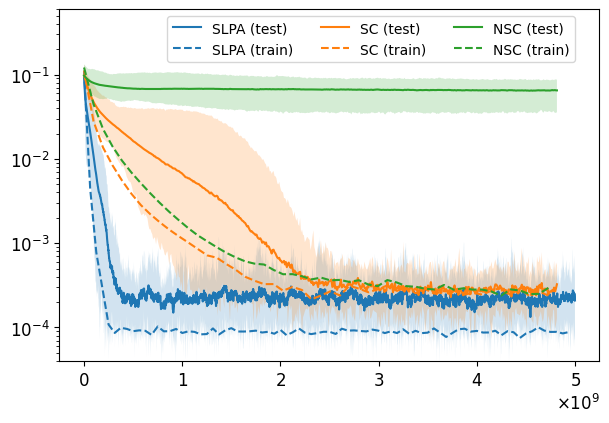

In [10]:
seed_list = range(20)
num_samp = 1000


fig, ax = plt.subplots(figsize=(6,4))
plt.yscale('log')
plt.ylim(4e-5, 0.6)


# number of shots used per iteration
shot_cbc = 1000*50*(12*2+1) # 1000 shots * 50 training data * (num_blocks + 1)
shot_sc = 1000*50*(12*8*2+1) # 1000 shots * 50 training data * (2*num_params + 1)
shot_nsc = 1000*50*(12*8*2+1) # 1000 shots * 50 training data * (2*num_params + 1)



# files
foldername = f"output_cbc_ns={num_samp}/"
ylist_cbc1 = []
for s in seed_list:
    ylist_cbc1.append(np.load(foldername + f'cbc_cost_seed={s}.npy'))

foldername = f"output_sc_ns={num_samp}/"
ylist_sc1 = []
for s in seed_list:
    ylist_sc1.append(np.load(foldername + f'sc_cost_seed={s}.npy'))
        
foldername = f"output_nsc_ns={num_samp}/"
ylist_nsc1 = []
for s in seed_list:
    ylist_nsc1.append(np.load(foldername + f'nsc_cost_seed={s}.npy'))
    

    
# files
foldername = f"output_cbc_ns={num_samp}/"
ylist_cbc2 = []
for s in seed_list:
    ylist_cbc2.append(np.load(foldername + f'cbc_test_seed={s}.npy'))
    
foldername = f"output_sc_ns={num_samp}/"
ylist_sc2 = []
for s in seed_list:
    ylist_sc2.append(np.load(foldername + f'sc_test_seed={s}.npy'))
    
foldername = f"output_nsc_ns={num_samp}/"
ylist_nsc2 = []
for s in seed_list:
    ylist_nsc2.append(np.load(foldername + f'nsc_test_seed={s}.npy'))

    
    
    
x_cbc = np.array( range(len(ylist_cbc1[0])) )
x_sc = np.array( range(len(ylist_sc1[0])) )
x_nsc = np.array( range(len(ylist_nsc1[0])) )
    
plot_error_fill(shot_cbc*x_cbc, ylist_cbc2, label='SLPA (test)')
plot_mean1(shot_cbc*x_cbc, ylist_cbc1, label='SLPA (train)', color='tab:blue')

plot_error_fill(shot_sc*x_sc, ylist_sc2, label='SC (test)')
plot_mean2(shot_sc*x_sc, ylist_sc1, label='SC (train)', color='tab:orange')

plot_error_fill(shot_nsc*x_nsc, ylist_nsc2, label='NSC (test)')
plot_mean2(shot_nsc*x_nsc, ylist_nsc1, label='NSC (train)', color='tab:green')
    

""" plot """
ax.xaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   
ax.ticklabel_format(style="sci", axis="x", scilimits=(9,9))   
ax.xaxis.offsetText.set_fontsize(12)

ax.tick_params(labelsize=12)

plt.legend(fontsize=10, ncol=3, loc=(0.2,0.85))

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.1, top=0.98) 
plt.savefig("result_summarized.pdf", bbox_inches='tight', pad_inches=0.05)